# IRIS DATASET

This project uses the classic Iris dataset to demonstrate unsupervised machine learning using the K-means clustering algorithm. The objective is to group Iris flower samples into clusters based on their physical attributes, such as sepal length, sepal width, petal length, and petal width and evaluate whether the algorithm can separate the different species based on their similarities.


In [58]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn import datasets
from sklearn.model_selection import train_test_split


In [45]:
sns.set()

## Load and Explore Data

Importing Iris flower data set and observing the available parameters.


In [46]:
data = pd.read_csv("iris.csv")
data.keys()

Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

In [47]:
data.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


Need to observe the diferent Species availabe in this dataset.

In [48]:
species = data['Species'].unique()
print(f"Species: {species}")

Species: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


Need to add a target value based on the Species name.

For this case:

    0 - Iris-setosa

    1 - Iris-versicolor

    2 - Iris-virginica

In [49]:
species_map = {
    "Iris-setosa": 0,
    "Iris-versicolor": 1,
    "Iris-virginica": 2}

data["target"] = data["Species"].map(species_map)
data.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,target
0,1,5.1,3.5,1.4,0.2,Iris-setosa,0
1,2,4.9,3.0,1.4,0.2,Iris-setosa,0
2,3,4.7,3.2,1.3,0.2,Iris-setosa,0
3,4,4.6,3.1,1.5,0.2,Iris-setosa,0
4,5,5.0,3.6,1.4,0.2,Iris-setosa,0


### Basic Descriptive Statistics

In [50]:
data = data.drop('Id', axis=1)
data.describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667,1.000000
std,0.828066,0.433594,1.764420,0.763161,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


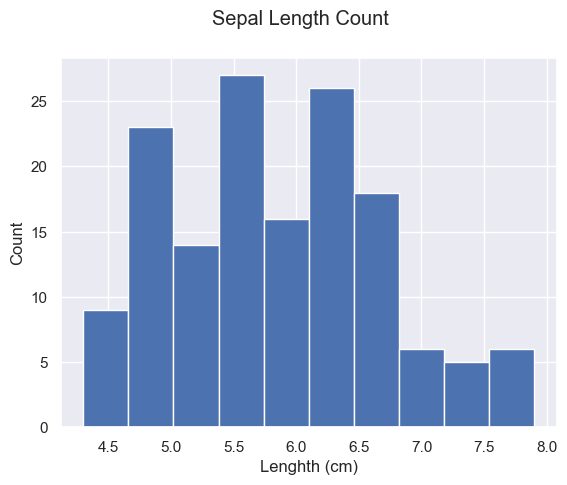

In [51]:
data["SepalLengthCm"].hist()
plt.suptitle("Sepal Length Count")
plt.ylabel("Count")
plt.xlabel("Lenghth (cm)")
plt.show()

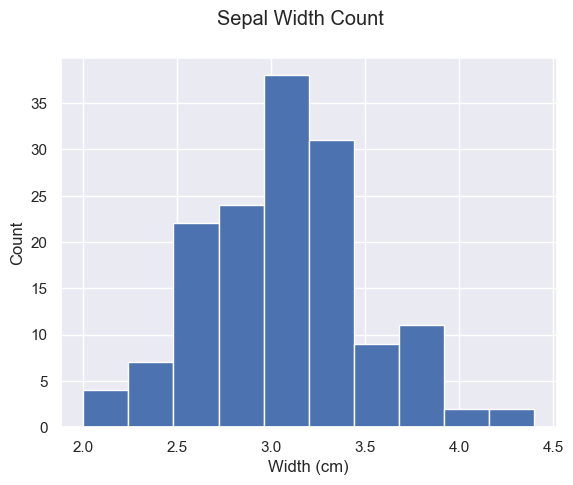

In [52]:
data["SepalWidthCm"].hist()
plt.suptitle("Sepal Width Count")
plt.ylabel("Count")
plt.xlabel("Width (cm)")
plt.show()

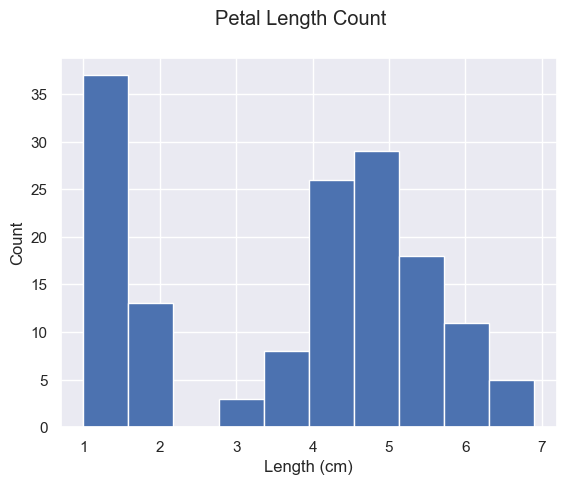

In [53]:
data["PetalLengthCm"].hist()
plt.suptitle("Petal Length Count")
plt.ylabel("Count")
plt.xlabel("Length (cm)")
plt.show()

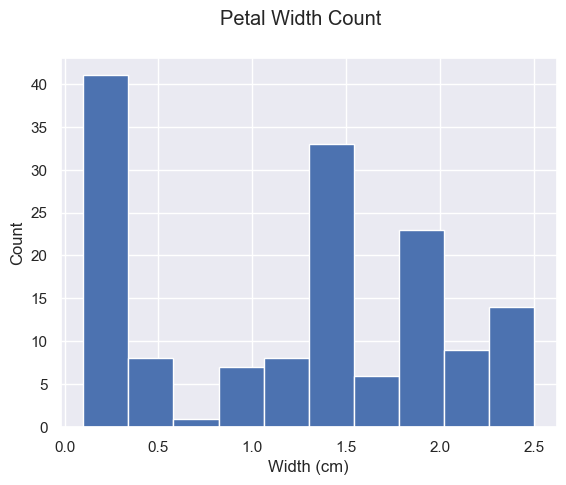

In [54]:
data["PetalWidthCm"].hist()
plt.suptitle("Petal Width Count")
plt.ylabel("Count")
plt.xlabel("Width (cm)")
plt.show()

## Exploratory Data Analysis (EDA) - Pairplots

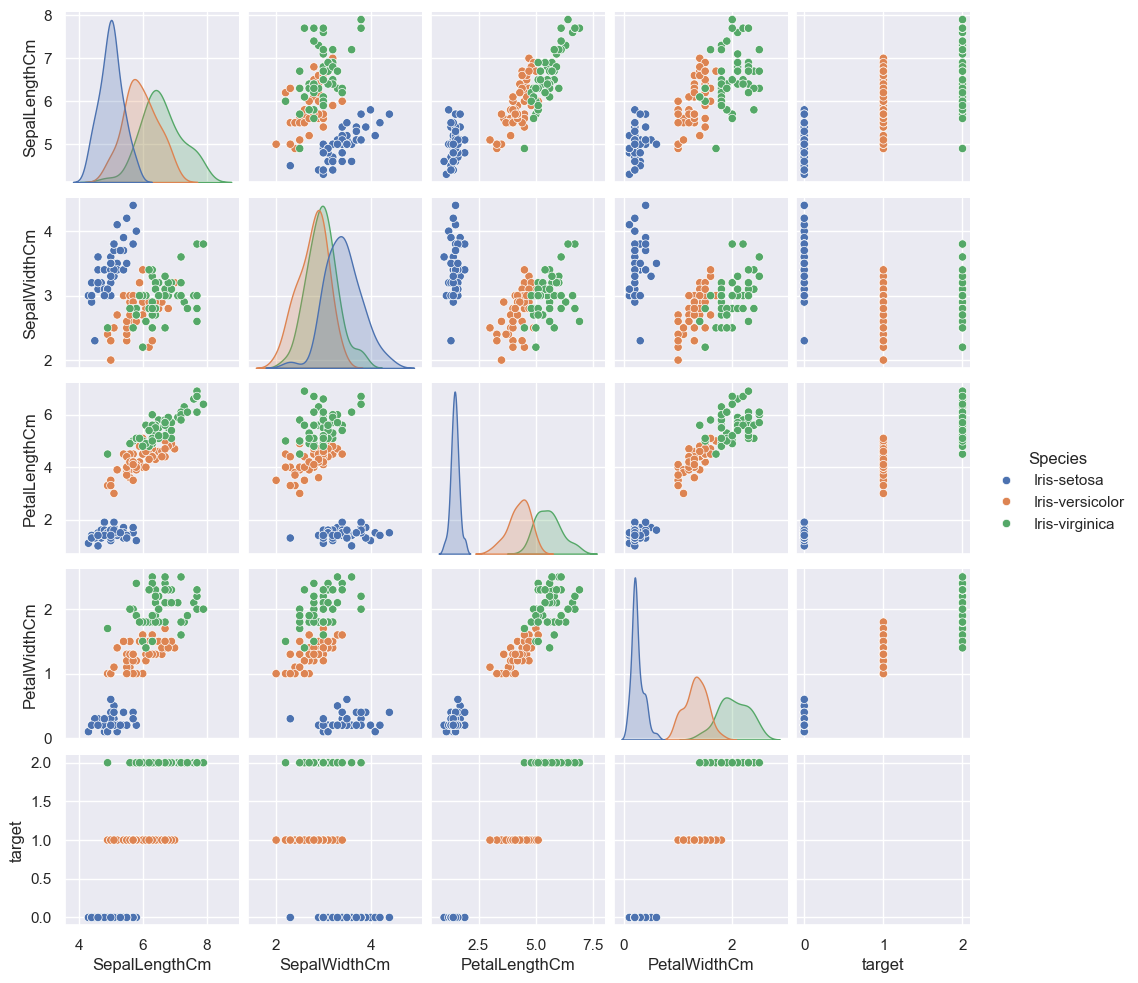

In [55]:
sns.pairplot(data, hue="Species", height=2)

## Train Test Split

Need to separate the data into two datasets: one for training and one for testing

In [59]:
df_train, df_test = train_test_split(data, test_size=0.25, random_state=1)

In [60]:
df_train.shape

(112, 6)

In [61]:
df_test.shape

(38, 6)

In [62]:
df_train.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,target
54,6.5,2.8,4.6,1.5,Iris-versicolor,1
108,6.7,2.5,5.8,1.8,Iris-virginica,2
112,6.8,3.0,5.5,2.1,Iris-virginica,2
17,5.1,3.5,1.4,0.3,Iris-setosa,0
119,6.0,2.2,5.0,1.5,Iris-virginica,2


In [ ]:
x_train = df_train.drop(columns=["Species", "target"]).values
y_train = df_train["target"].values


array([1, 2, 2, 0, 2, 2, 1, 2, 0, 0, 0, 1, 0, 0, 2, 2, 2, 2, 2, 1, 2, 1,
       0, 2, 2, 0, 0, 2, 0, 2, 2, 1, 1, 2, 2, 0, 1, 1, 2, 1, 2, 1, 0, 0,
       0, 2, 0, 1, 2, 2, 0, 0, 1, 0, 2, 1, 2, 2, 1, 2, 2, 1, 0, 1, 0, 1,
       1, 0, 1, 0, 0, 2, 2, 2, 0, 0, 1, 0, 2, 0, 2, 2, 0, 2, 0, 1, 0, 1,
       1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 2, 0, 0, 2, 1, 2, 1, 2, 2, 1,
       2, 0])

# Modeling

Now that we are starting with the modeling, I think it is important to declare the baseline. In this case, the simplest "model" would be one that declares 100% of the data be one specific Species, resulting in a 33% of accurracy since the dataset is evenly balanced. So in theory the model should beat this baseline.

## Simple Manual Modeling

Since the data set was observed to be almost perfectly separated when looking at the daata, it was decided to try to do it manually to later compare it to a ML model. After all the best way to do things will always be the simplest.


In [67]:
def single_festure_prediction(petal_length):
    """"Predict the species of iris based on petal length."""
    if petal_length < 2.5:
        return 0
    elif petal_length < 4.75:
        return 1
    else:
        return 2

In [69]:
df_train.columns

Index(['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species', 'target'],
      dtype='object')

In [70]:
x_train[:,2]

array([4.6, 5.8, 5.5, 1.4, 5. , 5.6, 4.6, 6.9, 1.7, 1.4, 1.4, 3.9, 1.5,
       1.3, 6.7, 5.4, 6.3, 5.6, 4.8, 4.5, 6.7, 4.2, 1.6, 5. , 4.9, 1.4,
       1.3, 5.8, 1.4, 4.9, 5.1, 4.4, 4.5, 5.7, 4.8, 1.6, 4. , 4.3, 5.5,
       3.3, 6. , 4. , 1.5, 1.5, 1.5, 5.7, 1.3, 5.1, 5.3, 5.1, 1.5, 1.7,
       4.1, 1.5, 6.1, 4.3, 6.6, 5.2, 4.4, 5.4, 6.1, 3.6, 1.5, 3.9, 1.3,
       3.8, 4.9, 1.6, 4.8, 1.6, 1.9, 5.6, 4.9, 5.9, 1.4, 1.5, 4.8, 1.5,
       5.1, 1.6, 5.2, 4.5, 1.4, 5.3, 1.1, 4.1, 1.4, 3.7, 3.5, 1.4, 1.4,
       3.3, 1. , 4.2, 4.7, 1.5, 4.7, 4.2, 4.5, 4.7, 5.1, 1.7, 1.6, 5.6,
       4. , 5.8, 3.5, 5.1, 5.5, 4.9, 5.6, 1.5])

In [74]:
manual_y_predictions = np.array([single_festure_prediction(length) for length in x_train[:,2]])
accuracy = np.average(manual_y_predictions == y_train)
print(f"Manual model accuracy: {accuracy:.2%}")

Manual model accuracy: 94.64%
